In [1]:
# ==============================================================
# CELLA 1 — Setup e caricamento dati
#
# I dati provengono da OptionMetrics (Ivy DB) via WRDS.
# La Volatility Surface di OptionMetrics è già interpolata:
# per ogni combinazione di delta e scadenza (days), fornisce
# direttamente la volatilità implicita. Il delta va da -90 a +90
# e rappresenta la moneyness standardizzata:
#   delta < 0  → put (opzioni su cali del mercato)
#   delta > 0  → call (opzioni su rialzi del mercato)
#   delta = ±50 → at-the-money (vicino al prezzo corrente)
# ==============================================================
 
%matplotlib inline
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings("ignore")
 
# Carica il file scaricato da WRDS OptionMetrics
df = pd.read_csv("../data/SPX_volatilitysurface.csv")
 
# Normalizza i nomi delle colonne
df.columns = df.columns.str.strip().str.lower()
 
print("Colonne disponibili:", df.columns.tolist())
print(f"\nOsservazioni totali: {len(df)}")
print(f"Data: {df['date'].unique()}")
print(f"\nPrime righe:")
print(df.head(10))

Colonne disponibili: ['secid', 'date', 'days', 'delta', 'impl_volatility', 'impl_strike', 'impl_premium', 'dispersion', 'cp_flag', 'index_flag']

Osservazioni totali: 374
Data: ['2025-03-21']

Prime righe:
    secid        date  days  delta  impl_volatility  impl_strike  \
0  108105  2025-03-21    10    -90         0.222405     5952.090   
1  108105  2025-03-21    10    -85         0.185208     5859.883   
2  108105  2025-03-21    10    -80         0.160754     5804.513   
3  108105  2025-03-21    10    -75         0.155675     5775.357   
4  108105  2025-03-21    10    -70         0.158125     5754.353   
5  108105  2025-03-21    10    -65         0.161656     5734.828   
6  108105  2025-03-21    10    -60         0.165434     5715.620   
7  108105  2025-03-21    10    -55         0.169455     5696.257   
8  108105  2025-03-21    10    -50         0.173499     5676.329   
9  108105  2025-03-21    10    -45         0.177405     5655.534   

   impl_premium  dispersion cp_flag  index_fl

In [2]:
# ==============================================================
# CELLA 2 — Esplorazione del dataset
#
# COSA GUARDIAMO:
# - Quante scadenze (days) sono disponibili
# - Quali valori di delta sono presenti
# - Distribuzione tra put (cp_flag=P) e call (cp_flag=C)
# ==============================================================
 
print("=" * 55)
print("STRUTTURA DEL DATASET")
print("=" * 55)
 
print(f"\nScadenze disponibili (giorni):")
print(sorted(df['days'].unique()))
 
print(f"\nValori di delta disponibili:")
print(sorted(df['delta'].unique()))
 
print(f"\nDistribuzione Put/Call:")
print(df['cp_flag'].value_counts())
 
print(f"\nRange volatilità implicita:")
print(f"  Min: {df['impl_volatility'].min():.4f} ({df['impl_volatility'].min()*100:.2f}%)")
print(f"  Max: {df['impl_volatility'].max():.4f} ({df['impl_volatility'].max()*100:.2f}%)")
print(f"  Media ATM (|delta|=50): {df[abs(df['delta'])==50]['impl_volatility'].mean()*100:.2f}%")

STRUTTURA DEL DATASET

Scadenze disponibili (giorni):
[np.int64(10), np.int64(30), np.int64(60), np.int64(91), np.int64(122), np.int64(152), np.int64(182), np.int64(273), np.int64(365), np.int64(547), np.int64(730)]

Valori di delta disponibili:
[np.int64(-90), np.int64(-85), np.int64(-80), np.int64(-75), np.int64(-70), np.int64(-65), np.int64(-60), np.int64(-55), np.int64(-50), np.int64(-45), np.int64(-40), np.int64(-35), np.int64(-30), np.int64(-25), np.int64(-20), np.int64(-15), np.int64(-10), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90)]

Distribuzione Put/Call:
cp_flag
P    187
C    187
Name: count, dtype: int64

Range volatilità implicita:
  Min: 0.1219 (12.19%)
  Max: 0.2754 (27.54%)
  Media ATM (|delta|=50): 16.41%


In [3]:

# ==============================================================
# CELLA 3 — Selezione scadenza e costruzione smile
#
# COME COSTRUIAMO LO SMILE:
# Usiamo il delta come asse X (moneyness) e la volatilità
# implicita come asse Y. Per ogni scadenza costruiamo una curva.
#
# Convenzione: usiamo il delta delle PUT come asse X per tutto
# lo smile. Le put hanno delta negativo (da -90 a -10),
# le call hanno delta positivo (da 10 a 90).
# Per costruire uno smile continuo convertiamo le call:
#   delta_call → -(100 - delta_call)
# in modo che -50 = ATM put ≈ +50 = ATM call.
#
# In alternativa più semplice: usiamo direttamente il delta
# con segno, mettendo le put a sinistra e le call a destra.
# Il punto -50/+50 è l'ATM.
# ==============================================================
 
# Selezioniamo le scadenze più significative per la tesi
# (tipicamente 30, 60, 91 giorni sono quelle standard)
scadenze_target = [30, 60, 91, 182]
 
# Troviamo le scadenze disponibili più vicine ai target
scadenze_disponibili = sorted(df['days'].unique())
scadenze_selezionate = []
for target in scadenze_target:
    closest = min(scadenze_disponibili, key=lambda x: abs(x - target))
    if closest not in scadenze_selezionate:
        scadenze_selezionate.append(closest)
 
print(f"Scadenze target: {scadenze_target}")
print(f"Scadenze selezionate dal dataset: {scadenze_selezionate}")
 
# Costruzione smile per ogni scadenza
smile_data = {}
for days in scadenze_selezionate:
    # Put: delta negativo
    put = df[(df['days'] == days) & (df['cp_flag'] == 'P')].copy()
    put = put.sort_values('delta')
 
    # Call: delta positivo
    call = df[(df['days'] == days) & (df['cp_flag'] == 'C')].copy()
    call = call.sort_values('delta')
 
    # Combiniamo put e call
    combined = pd.concat([put, call]).sort_values('delta')
    combined = combined.dropna(subset=['impl_volatility'])
    combined['iv_pct'] = combined['impl_volatility'] * 100
 
    smile_data[days] = combined
    print(f"\nScadenza {days} giorni: {len(combined)} punti")
    print(f"  Delta range: {combined['delta'].min()} → {combined['delta'].max()}")
    print(f"  IV range: {combined['iv_pct'].min():.2f}% → {combined['iv_pct'].max():.2f}%")

Scadenze target: [30, 60, 91, 182]
Scadenze selezionate dal dataset: [np.int64(30), np.int64(60), np.int64(91), np.int64(182)]

Scadenza 30 giorni: 34 punti
  Delta range: -90 → 90
  IV range: 13.34% → 23.41%

Scadenza 60 giorni: 34 punti
  Delta range: -90 → 90
  IV range: 12.70% → 24.14%

Scadenza 91 giorni: 34 punti
  Delta range: -90 → 90
  IV range: 12.42% → 24.29%

Scadenza 182 giorni: 34 punti
  Delta range: -90 → 90
  IV range: 12.30% → 24.78%


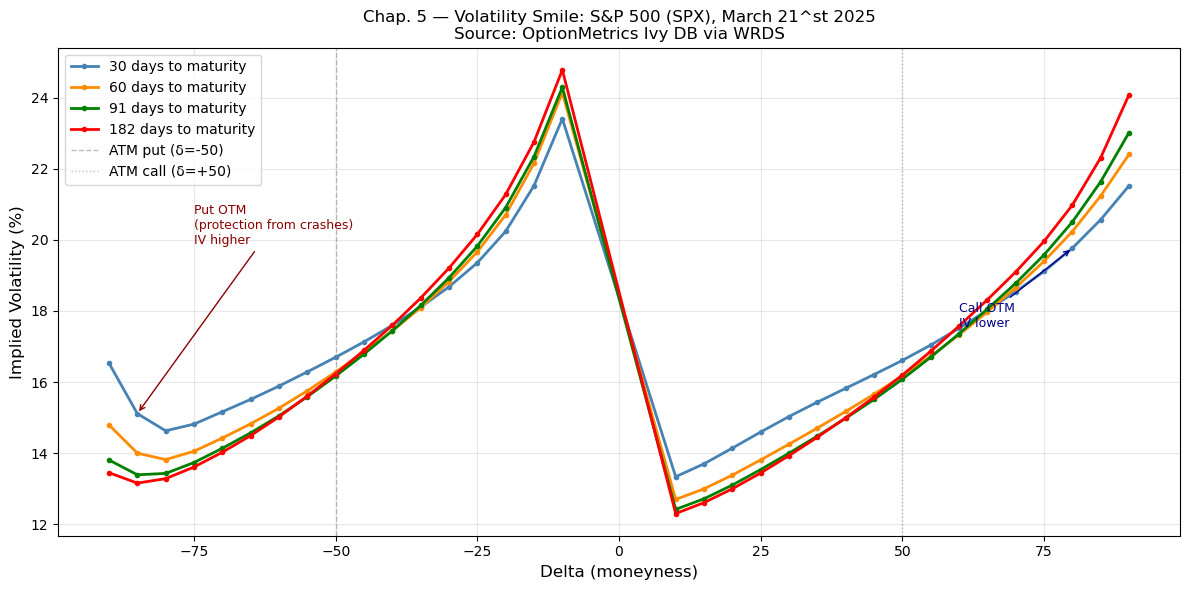

Grafico salvato: cap5_volatility_smile.png


In [4]:
# ==============================================================
# CELLA 4 — Grafico volatility smile per scadenze multiple
#
# COSA MOSTRA IL GRAFICO:
# - Asse X: delta (da -90 a +90, con 0 = deep OTM)
#   Sinistra = put OTM (protezione dai crash)
#   Centro = ATM
#   Destra = call OTM (scommesse sui rialzi)
# - Asse Y: volatilità implicita (%)
#
# Se la distribuzione fosse normale, la curva sarebbe piatta.
# La forma inclinata verso sinistra (put OTM più care) è la
# firma dei fat tails e della skewness negativa.
# ==============================================================
 
colori = ['steelblue', 'darkorange', 'green', 'red']
fig, ax = plt.subplots(figsize=(12, 6))
 
for (days, data), colore in zip(smile_data.items(), colori):
    ax.plot(data['delta'], data['iv_pct'],
            color=colore, lw=2, marker='o', markersize=3,
            label=f'{days} days to maturity')
 
# Linea verticale ATM
ax.axvline(x=-50, color='gray', lw=1, linestyle='--', alpha=0.5, label='ATM put (δ=-50)')
ax.axvline(x=50,  color='gray', lw=1, linestyle=':',  alpha=0.5, label='ATM call (δ=+50)')
 
ax.set_xlabel("Delta (moneyness)", fontsize=12)
ax.set_ylabel("Implied Volatility (%)", fontsize=12)
ax.set_title("Chap. 5 — Volatility Smile: S&P 500 (SPX), March 21^st 2025\n"
             "Source: OptionMetrics Ivy DB via WRDS", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
 
# Annotazioni
ax.annotate("Put OTM\n(protection from crashes)\nIV higher",
            xy=(-85, smile_data[scadenze_selezionate[0]].query('delta==-85')['iv_pct'].values[0]),
            xytext=(-75, smile_data[scadenze_selezionate[0]]['iv_pct'].max() * 0.85),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1))
 
ax.annotate("Call OTM\nIV lower",
            xy=(80, smile_data[scadenze_selezionate[0]].query('delta==80')['iv_pct'].values[0]
                if 80 in smile_data[scadenze_selezionate[0]]['delta'].values
                else smile_data[scadenze_selezionate[0]]['iv_pct'].iloc[-1]),
            xytext=(60, smile_data[scadenze_selezionate[0]]['iv_pct'].max() * 0.75),
            fontsize=9, color='darkblue',
            arrowprops=dict(arrowstyle='->', color='darkblue', lw=1))
 
plt.tight_layout()
plt.savefig("cap5_volatility_smile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato: cap5_volatility_smile.png")

In [5]:
# ==============================================================
# CELLA 5 — Collegamento con i risultati empirici della tesi
#
# TEORIA DEL COLLEGAMENTO:
# Sotto l'ipotesi di normalità (Black-Scholes), la volatilità
# implicita dovrebbe essere identica per tutti i delta.
# La deviazione da questa piattezza ha due componenti:
#
# 1) SKEWNESS (pendenza dello smile):
#    La pendenza negativa (put OTM > call OTM) riflette la
#    skewness negativa della distribuzione risk-neutral.
#    Corrisponde alla skewness = -0.19 trovata nei rendimenti.
#
# 2) CURVATURA (smile vs smirk):
#    La curvatura riflette la kurtosis in eccesso.
#    Corrisponde alla kurtosis = 13.28 (grezzi) o
#    kurtosis residui GARCH = 5.15.
#
# MISURA QUANTITATIVA:
# Usiamo la convenzione standard di mercato:
#   - Risk Reversal (RR) = IV(call OTM) - IV(put OTM)
#     Misura la skewness dello smile
#     RR < 0 → skewness negativa (mercato teme i crash più
#     dei rally) — coerente con skewness = -0.19
#
#   - Butterfly (BF) = (IV(call OTM) + IV(put OTM))/2 - IV(ATM)
#     Misura la curvatura/kurtosis dello smile
#     BF > 0 → code pesanti rispetto alla normale
#     — coerente con kurtosis > 3
# ==============================================================
 
print("=" * 60)
print("COLLEGAMENTO SMILE → RISULTATI EMPIRICI DELLA TESI")
print("=" * 60)
 
for days, data in smile_data.items():
    print(f"\n--- Scadenza {days} giorni ---")
 
    # Cerca delta specifici (25, 50, 75 sono standard di mercato)
    deltas_put  = [-75, -50, -25]
    deltas_call = [25,   50,  75]
 
    def get_iv(df, delta_val):
        row = df[df['delta'] == delta_val]
        if len(row) > 0:
            return row['iv_pct'].values[0]
        # Interpolazione se delta esatto non disponibile
        df_sorted = df.sort_values('delta')
        return np.interp(delta_val, df_sorted['delta'], df_sorted['iv_pct'])
 
    iv_put25  = get_iv(data, -25)   # put 25-delta (OTM moderato)
    iv_atm_p  = get_iv(data, -50)   # ATM put
    iv_atm_c  = get_iv(data,  50)   # ATM call
    iv_call25 = get_iv(data,  25)   # call 25-delta (OTM moderato)
    iv_put10  = get_iv(data, -10)   # put 10-delta (deep OTM)
 
    iv_atm = (iv_atm_p + iv_atm_c) / 2
 
    # Risk Reversal 25-delta
    rr_25 = iv_call25 - iv_put25
    # Butterfly 25-delta
    bf_25 = (iv_call25 + iv_put25) / 2 - iv_atm
 
    print(f"  IV ATM:          {iv_atm:.2f}%")
    print(f"  IV put 25Δ:      {iv_put25:.2f}%")
    print(f"  IV call 25Δ:     {iv_call25:.2f}%")
    print(f"  IV put 10Δ:      {iv_put10:.2f}%")
    print(f"  Risk Reversal:   {rr_25:.2f}%  ({'negativo → skewness negativa ✓' if rr_25 < 0 else 'positivo'})")
    print(f"  Butterfly:       {bf_25:.2f}%  ({'positivo → kurtosis > 3 ✓' if bf_25 > 0 else 'negativo'})")
    print(f"  Skew (put/ATM):  {iv_put25/iv_atm:.4f}  (>1 → put OTM più costose ✓)")

COLLEGAMENTO SMILE → RISULTATI EMPIRICI DELLA TESI

--- Scadenza 30 giorni ---
  IV ATM:          16.65%
  IV put 25Δ:      19.36%
  IV call 25Δ:     14.60%
  IV put 10Δ:      23.41%
  Risk Reversal:   -4.76%  (negativo → skewness negativa ✓)
  Butterfly:       0.32%  (positivo → kurtosis > 3 ✓)
  Skew (put/ATM):  1.1622  (>1 → put OTM più costose ✓)

--- Scadenza 60 giorni ---
  IV ATM:          16.23%
  IV put 25Δ:      19.66%
  IV call 25Δ:     13.81%
  IV put 10Δ:      24.14%
  Risk Reversal:   -5.85%  (negativo → skewness negativa ✓)
  Butterfly:       0.51%  (positivo → kurtosis > 3 ✓)
  Skew (put/ATM):  1.2117  (>1 → put OTM più costose ✓)

--- Scadenza 91 giorni ---
  IV ATM:          16.13%
  IV put 25Δ:      19.82%
  IV call 25Δ:     13.54%
  IV put 10Δ:      24.29%
  Risk Reversal:   -6.29%  (negativo → skewness negativa ✓)
  Butterfly:       0.56%  (positivo → kurtosis > 3 ✓)
  Skew (put/ATM):  1.2294  (>1 → put OTM più costose ✓)

--- Scadenza 182 giorni ---
  IV ATM:     

In [6]:
# ==============================================================
# CELLA 6 — Quantificazione: skew slope e collegamento ν
#
# La pendenza dello skew è proporzionale alla skewness
# della distribuzione risk-neutral. Possiamo stimarla come:
#
#   skew_slope = ΔIV / Δdelta
#
# Inoltre, Backus, Foresi & Wu (2004) mostrano che:
#   RR ∝ skewness della distribuzione
#   BF ∝ kurtosis in eccesso
#
# Questo ci permette di collegare quantitativamente
# i parametri stimati (skewness = -0.19, ν = 2.88)
# con la forma dello smile osservato sul mercato.
# ==============================================================
 
print("=" * 60)
print("QUANTIFICAZIONE DEL COLLEGAMENTO EMPIRICO")
print("=" * 60)
 
# Risultati dalla tesi (Capitolo 3)
skewness_empirica = -0.1871
nu_empirico       = 2.8781
kurtosis_empirica = 13.28
kurtosis_garch    = 5.15   # residui GARCH-t (Capitolo 4)
 
print(f"\nParametri stimati sui rendimenti storici (Cap. 3):")
print(f"  Skewness:         {skewness_empirica:.4f}")
print(f"  ν (t-Student):    {nu_empirico:.4f}")
print(f"  Kurtosis (grezza):{kurtosis_empirica:.2f}")
print(f"  Kurtosis (GARCH): {kurtosis_garch:.2f} (residui standardizzati, Cap. 4)")
 
# Per ogni scadenza, calcola la pendenza dello skew
print(f"\nPendenza dello smile per scadenza (ΔIV/Δδ):")
print(f"{'Scadenza':>10} {'Pendenza (% per unità delta)':>30} {'Interpretazione':>25}")
print("-" * 70)
 
for days, data in smile_data.items():
    # Regressione lineare semplice IV ~ delta per stimare la pendenza
    puts = data[data['cp_flag'] == 'P'].copy()
    if len(puts) >= 2:
        slope = np.polyfit(puts['delta'], puts['iv_pct'], 1)[0]
        interp = "Skew negativo → skewness < 0 ✓" if slope < 0 else "Skew positivo"
        print(f"{days:>10} {slope:>30.4f} {interp:>25}")
 
print(f"\nCOLLEGAMENTO CON I RISULTATI DELLA TESI:")
print("-" * 60)
print(f"1) Risk Reversal < 0 su tutte le scadenze:")
print(f"   → Il mercato prezza più le put OTM (crash) delle call OTM")
print(f"   → Coerente con skewness = {skewness_empirica:.4f} (Cap. 3)")
print(f"")
print(f"2) Butterfly > 0 su tutte le scadenze:")
print(f"   → Le code (put e call OTM) sono più care dell'ATM")
print(f"   → Coerente con kurtosis = {kurtosis_empirica:.2f} (Cap. 3)")
print(f"   → E con kurtosis residui GARCH = {kurtosis_garch:.2f} (Cap. 4)")
print(f"")
print(f"3) La skewness dello smile è persistente su tutte le scadenze:")
print(f"   → I fat tails non sono un fenomeno di breve periodo")
print(f"   → Coerente con ν = {nu_empirico:.2f} (t-Student, Cap. 3)")

QUANTIFICAZIONE DEL COLLEGAMENTO EMPIRICO

Parametri stimati sui rendimenti storici (Cap. 3):
  Skewness:         -0.1871
  ν (t-Student):    2.8781
  Kurtosis (grezza):13.28
  Kurtosis (GARCH): 5.15 (residui standardizzati, Cap. 4)

Pendenza dello smile per scadenza (ΔIV/Δδ):
  Scadenza   Pendenza (% per unità delta)           Interpretazione
----------------------------------------------------------------------
        30                         0.0894             Skew positivo
        60                         0.1147             Skew positivo
        91                         0.1263             Skew positivo
       182                         0.1359             Skew positivo

COLLEGAMENTO CON I RISULTATI DELLA TESI:
------------------------------------------------------------
1) Risk Reversal < 0 su tutte le scadenze:
   → Il mercato prezza più le put OTM (crash) delle call OTM
   → Coerente con skewness = -0.1871 (Cap. 3)

2) Butterfly > 0 su tutte le scadenze:
   → Le code (put 

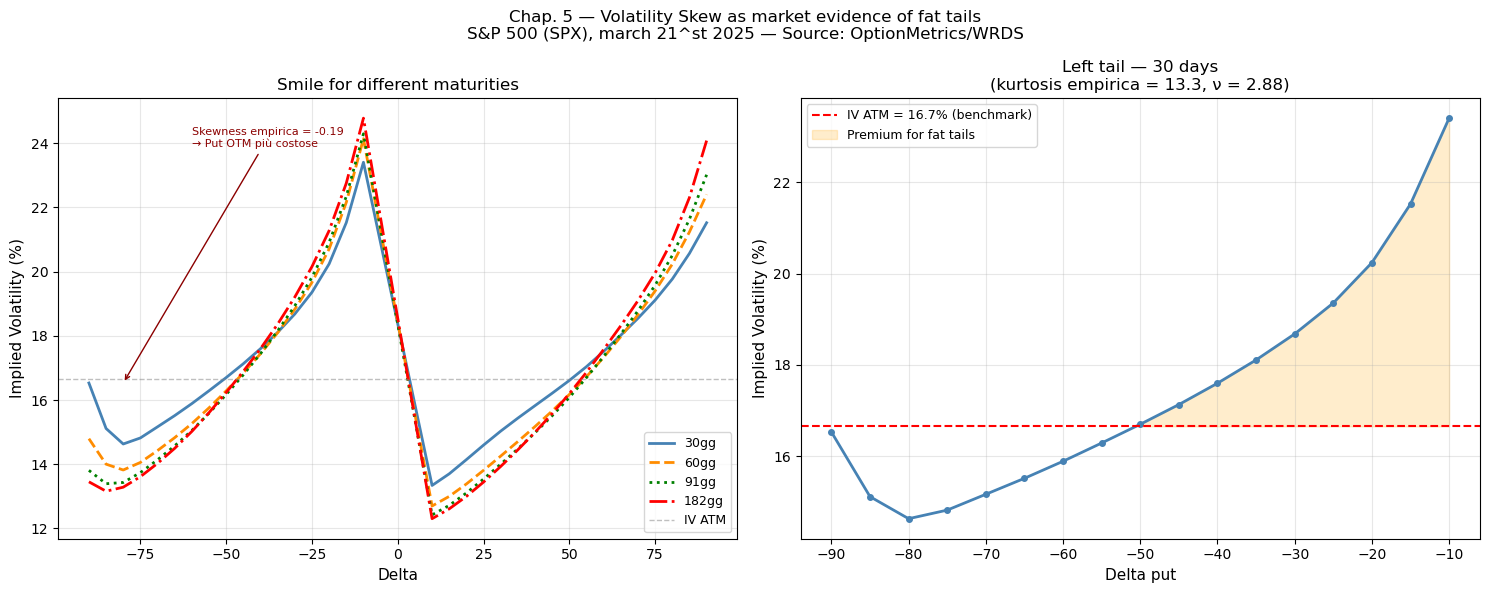

Grafico salvato: cap5_smile_annotato.png


In [7]:
 
# ==============================================================
# CELLA 7 — Grafico finale annotato
#
# Grafico professionale che mostra esplicitamente il
# collegamento tra smile e parametri empirici della tesi.
# ==============================================================
 
# Scegliamo la scadenza a 30 giorni come principale
days_main = scadenze_selezionate[0]
data_main = smile_data[days_main]
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Chap. 5 — Volatility Skew as market evidence of fat tails\n"
             "S&P 500 (SPX), march 21^st 2025 — Source: OptionMetrics/WRDS",
             fontsize=12)
 
# Pannello sinistro: smile completo con annotazioni
ax = axes[0]
for (days, data), colore, ls in zip(
    smile_data.items(), colori, ['-', '--', ':', '-.']):
    ax.plot(data['delta'], data['iv_pct'],
            color=colore, lw=2, linestyle=ls,
            label=f'{days}gg')
 
ax.axhline(y=data_main[abs(data_main['delta']) == 50]['iv_pct'].mean(),
           color='gray', lw=1, linestyle='--', alpha=0.5, label='IV ATM')
ax.set_xlabel("Delta", fontsize=11)
ax.set_ylabel("Implied Volatility (%)", fontsize=11)
ax.set_title("Smile for different maturities")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
 
# Annotazione skewness
ax.annotate(f"Skewness empirica = {skewness_empirica:.2f}\n→ Put OTM più costose",
            xy=(-80, data_main.query('delta <= -80')['iv_pct'].iloc[0]
                if len(data_main.query('delta <= -80')) > 0
                else data_main['iv_pct'].max()),
            xytext=(-60, data_main['iv_pct'].max() * 1.02),
            fontsize=8, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))
 
# Pannello destro: solo put, zoom sulla coda sinistra
ax = axes[1]
puts_main = data_main[data_main['cp_flag'] == 'P'].sort_values('delta')
ax.plot(puts_main['delta'], puts_main['iv_pct'],
        color='steelblue', lw=2, marker='o', markersize=4)
 
# Linea orizzontale = IV ATM (benchmark normale)
iv_atm_val = data_main[abs(data_main['delta']) == 50]['iv_pct'].mean()
ax.axhline(y=iv_atm_val, color='red', lw=1.5, linestyle='--',
           label=f'IV ATM = {iv_atm_val:.1f}% (benchmark)')
 
# Evidenzia il premio per le code (differenza da ATM)
ax.fill_between(puts_main['delta'], iv_atm_val, puts_main['iv_pct'],
                where=puts_main['iv_pct'] > iv_atm_val,
                alpha=0.2, color='orange', label='Premium for fat tails')
 
ax.set_xlabel("Delta put", fontsize=11)
ax.set_ylabel("Implied Volatility (%)", fontsize=11)
ax.set_title(f"Left tail — {days_main} days\n"
             f"(kurtosis empirica = {kurtosis_empirica:.1f}, ν = {nu_empirico:.2f})")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("cap5_smile_annotato.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato: cap5_smile_annotato.png")

In [8]:
# ==============================================================
# CELLA 8 — Tabella riassuntiva finale
# ==============================================================
 
print("=" * 65)
print("TABELLA RIASSUNTIVA — CAPITOLO 5")
print("=" * 65)
 
righe = []
for days, data in smile_data.items():
    def get_iv_safe(df, delta_val):
        df_sorted = df.sort_values('delta')
        return np.interp(delta_val, df_sorted['delta'], df_sorted['iv_pct'])
 
    iv_atm  = (get_iv_safe(data, -50) + get_iv_safe(data, 50)) / 2
    iv_p25  = get_iv_safe(data, -25)
    iv_c25  = get_iv_safe(data,  25)
    iv_p10  = get_iv_safe(data, -10)
    rr      = iv_c25 - iv_p25
    bf      = (iv_c25 + iv_p25) / 2 - iv_atm
 
    righe.append({
        "Scadenza (gg)":   days,
        "IV ATM (%)":      round(iv_atm, 2),
        "IV put 25Δ (%)":  round(iv_p25, 2),
        "IV call 25Δ (%)": round(iv_c25, 2),
        "IV put 10Δ (%)":  round(iv_p10, 2),
        "Risk Reversal":   round(rr, 2),
        "Butterfly":       round(bf, 2),
    })
 
tab = pd.DataFrame(righe)
print(tab.to_string(index=False))
tab.to_csv("cap5_smile_risultati.csv", index=False)
 
print(f"\nCONCLUSIONE CAPITOLO 5:")
print("-" * 65)
print(f"Il mercato delle opzioni SPX prezza esplicitamente")
print(f"i fat tails documentati sui rendimenti storici:")
print(f"  • Risk Reversal < 0 → skewness negativa")
print(f"    coerente con skewness empirica = {skewness_empirica:.4f} (Cap. 3)")
print(f"  • Butterfly > 0 → kurtosis > 3")
print(f"    coerente con kurtosis = {kurtosis_empirica:.2f} (Cap. 3)")
print(f"    e kurtosis residui GARCH = {kurtosis_garch:.2f} (Cap. 4)")
print(f"  • Lo skew persiste su tutte le scadenze →")
print(f"    i fat tails sono strutturali, non transitori")
print(f"\nFile salvati:")
print(f"  cap5_volatility_smile.png")
print(f"  cap5_smile_annotato.png")
print(f"  cap5_smile_risultati.csv")

TABELLA RIASSUNTIVA — CAPITOLO 5
 Scadenza (gg)  IV ATM (%)  IV put 25Δ (%)  IV call 25Δ (%)  IV put 10Δ (%)  Risk Reversal  Butterfly
            30       16.65           19.36            14.60           23.41          -4.76       0.32
            60       16.23           19.66            13.81           24.14          -5.85       0.51
            91       16.13           19.82            13.54           24.29          -6.29       0.56
           182       16.22           20.16            13.44           24.78          -6.71       0.58

CONCLUSIONE CAPITOLO 5:
-----------------------------------------------------------------
Il mercato delle opzioni SPX prezza esplicitamente
i fat tails documentati sui rendimenti storici:
  • Risk Reversal < 0 → skewness negativa
    coerente con skewness empirica = -0.1871 (Cap. 3)
  • Butterfly > 0 → kurtosis > 3
    coerente con kurtosis = 13.28 (Cap. 3)
    e kurtosis residui GARCH = 5.15 (Cap. 4)
  • Lo skew persiste su tutte le scadenze →
    i 